###### 2025.04.03
- CIC IoMT Intrusion data 2024
- by Eui Cheol. Kim

### EDA
###### 2024.04.03
    - dataload and 

In [1]:
import os 
import pandas as pd 
from pandas import DataFrame


dataPath = '/home/augustine77/mylab/sim/sim/Project_IoT_Attack/data/CIC_2024/Wifi_and_MQTT'

setPath = {
    "device type" : [ "bluetooth","Wifi_and_MQTT"],
    "data type" : {
                    "train": "attacks/CSV/train/",
                    "test": "attacks/CSV/test/",
                }
}  

type = "train"
path = os.path.join(dataPath,setPath["data type"][type])
fileList = [file for file in os.listdir(path)]


In [4]:
tag_01 = fileList[0].split('_')
print(tag_01)
tag_02 = tag_01[1].split('-')
print(tag_02)

['TCP', 'IP-DoS-SYN1', 'train.pcap.csv']
['IP', 'DoS', 'SYN1']


In [5]:
df = DataFrame()
rowLen = 0
for file in fileList[:10]:
    d = pd.read_csv(os.path.join(path,file))
    tag1 = file.split('_')
    tag2 = tag1[1].split('-')
    print(f"tag1 : {tag1}")
    print(f"tag2 : {tag2} \n")
    # d['class_1'] = tag1[0]
    # d['class_2'] = tag2[0]
    # d['class_3'] = tag2[1]
    # d['class_4'] = tag2[2]
    # rowLen += d.shape[0]
    # df = pd.concat([df,d], axis=0)
    

# print(f"data row count : {rowLen}")
df

tag1 : ['TCP', 'IP-DoS-SYN1', 'train.pcap.csv']
tag2 : ['IP', 'DoS', 'SYN1'] 

tag1 : ['Recon-OS', 'Scan', 'train.pcap.csv']
tag2 : ['Scan'] 

tag1 : ['TCP', 'IP-DDoS-UDP8', 'train.pcap.csv']
tag2 : ['IP', 'DDoS', 'UDP8'] 

tag1 : ['TCP', 'IP-DoS-ICMP4', 'train.pcap.csv']
tag2 : ['IP', 'DoS', 'ICMP4'] 

tag1 : ['TCP', 'IP-DDoS-SYN4', 'train.pcap.csv']
tag2 : ['IP', 'DDoS', 'SYN4'] 

tag1 : ['TCP', 'IP-DDoS-ICMP1', 'train.pcap.csv']
tag2 : ['IP', 'DDoS', 'ICMP1'] 

tag1 : ['TCP', 'IP-DoS-TCP3', 'train.pcap.csv']
tag2 : ['IP', 'DoS', 'TCP3'] 

tag1 : ['MQTT-DDoS-Connect', 'Flood', 'train.pcap.csv']
tag2 : ['Flood'] 

tag1 : ['Recon-VulScan', 'train.pcap.csv']
tag2 : ['train.pcap.csv'] 

tag1 : ['TCP', 'IP-DDoS-ICMP8', 'train.pcap.csv']
tag2 : ['IP', 'DDoS', 'ICMP8'] 



""


###### 2025.04.27
- CIC IoMT Intrusion data 2024

#### EDA
    - data.info
    - check data label balance
    - check outlier&missing data 
    - feature 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import data_setting, predict_setting
from dataFactory import Read_DataList, CIC_Dataset


In [7]:
# set data path & level 
filePath = data_setting["filePath"]
level = 1 # data_setting["level"]
scale = data_setting["scale"]
val_size = data_setting["val_size"]
pred_filePath = predict_setting["pred_filePath"]

# set train with dataset
num_workers = data_setting["num_workers"]
batch_size = data_setting["batch_size"]
drop_last = data_setting["drop_last"]
shuffle_flag = data_setting["shuffle_flag"]       
add_test = True

dataloader = Read_DataList(filePath, val_size, level, scale, add_test)


 - [ Start Read Data-List And Load Data-files ] - 

Now Loading........TCP_IP-DoS-SYN1_train.pcap.csv...Check.left/Total_file..(51/51)
Skip:..Recon-OS_Scan_train.pcap.csv..is..in...the..List..of..skip..Category..Class...(50/51)
Now Loading........TCP_IP-DDoS-UDP8_train.pcap.csv...Check.left/Total_file..(49/51)
Now Loading........TCP_IP-DoS-ICMP4_train.pcap.csv...Check.left/Total_file..(48/51)
Now Loading........TCP_IP-DDoS-SYN4_train.pcap.csv...Check.left/Total_file..(47/51)
Now Loading........TCP_IP-DDoS-ICMP1_train.pcap.csv...Check.left/Total_file..(46/51)
Now Loading........TCP_IP-DoS-TCP3_train.pcap.csv...Check.left/Total_file..(45/51)
Now Loading........MQTT-DDoS-Connect_Flood_train.pcap.csv...Check.left/Total_file..(44/51)
Skip:..Recon-VulScan_train.pcap.csv..is..in...the..List..of..skip..Category..Class...(43/51)
Now Loading........TCP_IP-DDoS-ICMP8_train.pcap.csv...Check.left/Total_file..(42/51)
Now Loading........TCP_IP-DDoS-TCP4_train.pcap.csv...Check.left/Total_file..(41/51

In [8]:
# 데이터를 읽어 들이고 데이터의 모양을 확인
train,train_label = dataloader.get_train_data()
val, val_label = dataloader.get_val_data()
test, test_label = dataloader.get_test_data()
print (f"train input shape: {train.shape} \ntrain_label shape: {train_label.shape}\n")
print (f"val input shape: {val.shape} \nval_label shape: {val_label.shape}\n")
print (f"test input shape: {test.shape} \ntest_label shape: {test_label.shape}\n \n")

oneHot = dataloader.get_oneHot()
print(f"label_oneHot_categories: {oneHot.categories_}")

colnames = dataloader.colnames
# colnames = colnames.remove('class_1')
print(f"feature column name's: {colnames}")
print(f"fueature columns length: {len(colnames)}")


train input shape: (5628742, 45) 
train_label shape: (5628742, 3)

val input shape: (1407186, 45) 
val_label shape: (1407186, 3)

test input shape: (1583015, 45) 
test_label shape: (1583015, 3)
 

label_oneHot_categories: [array(['Benign', 'DDoS', 'DoS'], dtype=object)]
feature column name's: ['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'class_1']
fueature columns length: 46


In [9]:
# trasform to DataFrame
df_train_label = pd.DataFrame(train_label, columns=[oneHot.categories_[0]])
df_val_label = pd.DataFrame(val_label, columns=[oneHot.categories_[0]])
df_test_label = pd.DataFrame(test_label, columns=[oneHot.categories_[0]])

# label count plot
def plot_column_sums(df, flag:str):
    column_sums = df.sum()
    print(f"{flag.upper} columns count : \n{column_sums}")
    plt.figure(figsize=(10, 6))
    column_sums.plot(kind='bar')
    plt.title(f'Sum of {flag.upper()}\'s Each Column')
    plt.xlabel('Columns')
    plt.ylabel('Sum')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.legend(loc=1)
    plt.show()


In [13]:
for i, n in enumerate(df_train_label.sum()):
    print(f"percentage of {n} : {round(df_train_label.sum()[i]/df_train_label.shape[0],3)}")

percentage of 154184.0 : 0.027
percentage of 3984313.0 : 0.708
percentage of 1490245.0 : 0.265


<built-in method upper of str object at 0x7465e0080830> columns count : 
Benign     154184.0
DDoS      3984313.0
DoS       1490245.0
dtype: float64


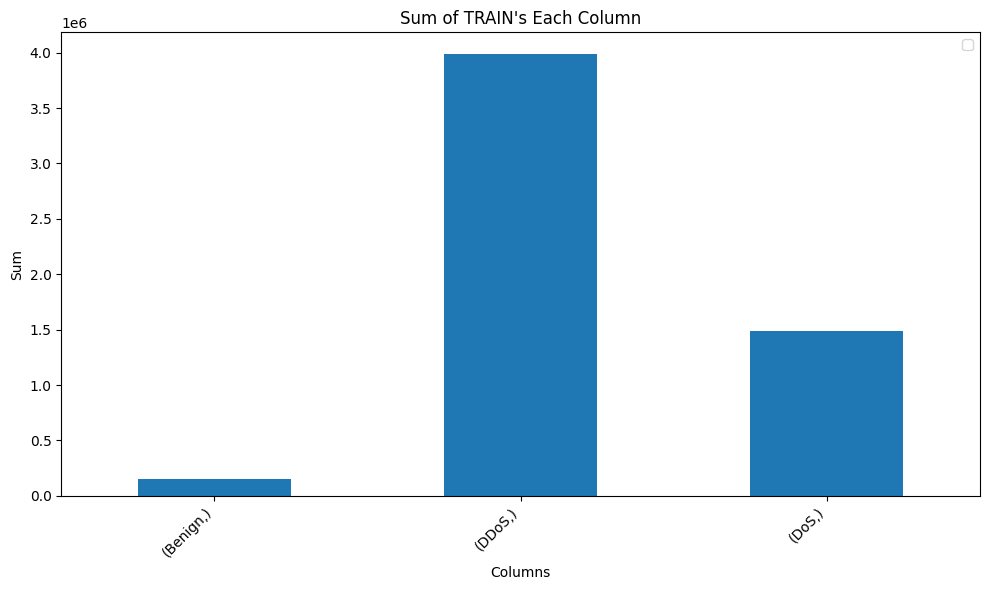

<built-in method upper of str object at 0x7465e6efcc20> columns count : 
Benign     38548.0
DDoS      996205.0
DoS       372433.0
dtype: float64


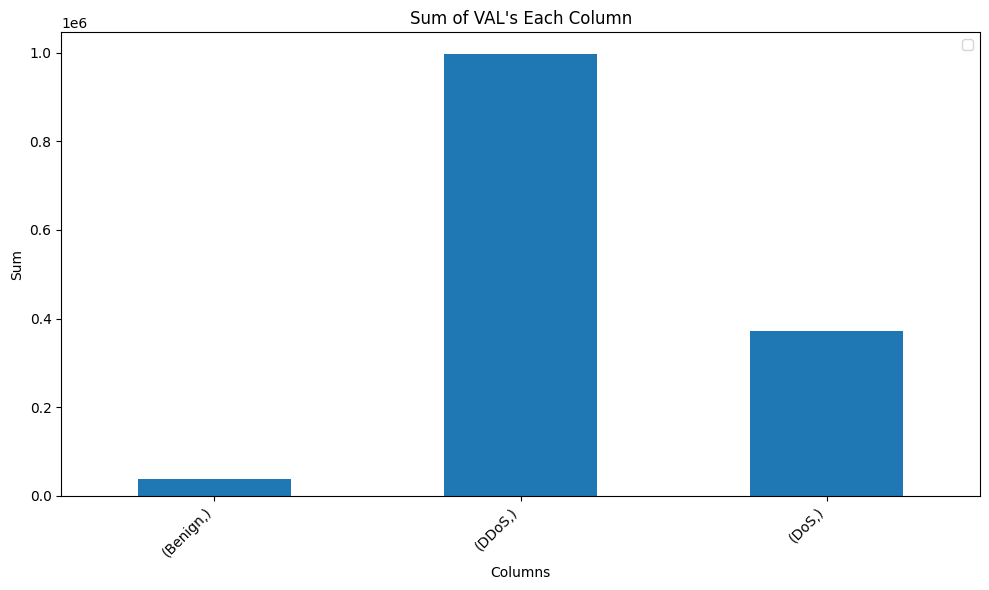

<built-in method upper of str object at 0x7465e5507b70> columns count : 
Benign      37607.0
DDoS      1117096.0
DoS        428312.0
dtype: float64


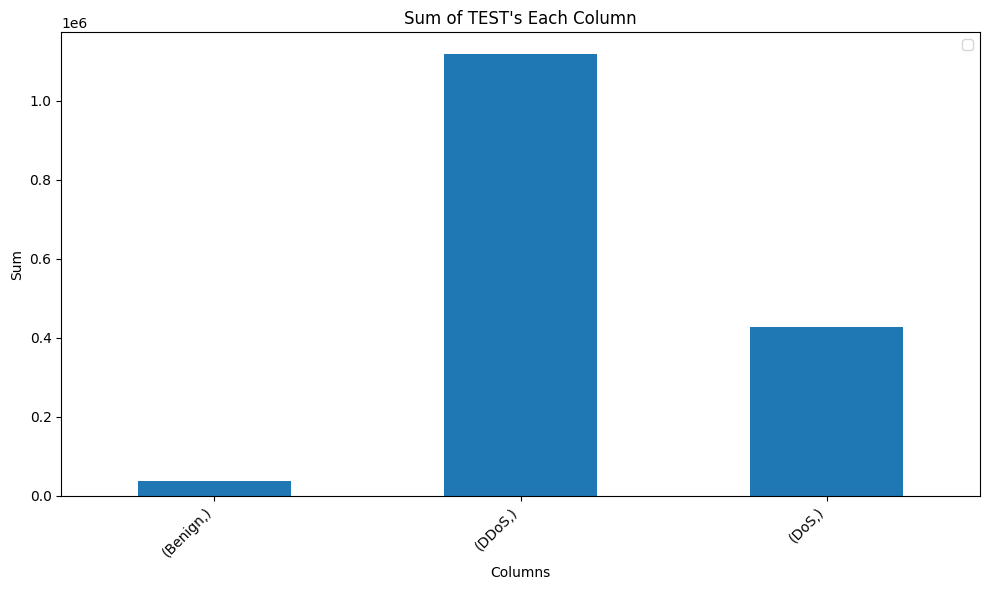

In [10]:
plot_column_sums(df_train_label, "train")
plot_column_sums(df_val_label, "val")
plot_column_sums(df_test_label, "test")

In [6]:
len(colnames)
colnames.remove('class_1')
colnames

['Header_Length',
 'Protocol Type',
 'Duration',
 'Rate',
 'Srate',
 'Drate',
 'fin_flag_number',
 'syn_flag_number',
 'rst_flag_number',
 'psh_flag_number',
 'ack_flag_number',
 'ece_flag_number',
 'cwr_flag_number',
 'ack_count',
 'syn_count',
 'fin_count',
 'rst_count',
 'HTTP',
 'HTTPS',
 'DNS',
 'Telnet',
 'SMTP',
 'SSH',
 'IRC',
 'TCP',
 'UDP',
 'DHCP',
 'ARP',
 'ICMP',
 'IGMP',
 'IPv',
 'LLC',
 'Tot sum',
 'Min',
 'Max',
 'AVG',
 'Std',
 'Tot size',
 'IAT',
 'Number',
 'Magnitue',
 'Radius',
 'Covariance',
 'Variance',
 'Weight']

In [7]:
# train transform to dataframe
train_label_re = oneHot.inverse_transform(train_label)
train_label_re.shape # 1407186, 1
train.shape # (1407186, 45)
df_train = pd.DataFrame(train, columns=colnames)
df_train["class"] = train_label_re[:,0]
df_train.head()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,class
0,-0.110354,-0.325049,-0.099514,-0.389796,-0.389796,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001011,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
1,-0.110354,-0.325049,-0.099514,-0.389673,-0.389673,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001010,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
2,-0.110354,-0.325049,-0.099514,-0.386914,-0.386914,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001003,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
3,0.657770,-0.325049,-0.099514,-0.389798,-0.389798,0.0,-0.149552,-0.462332,-0.282124,4.974796,...,0.193904,0.213661,6.022331,6.017068,0.681844,0.193817,-0.112087,4.070029,6.025722,Benign
4,-0.110628,-1.114569,-0.099514,-0.389703,-0.389703,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.218150,-0.000168,0.001476,-0.421699,-0.158976,-0.120588,-0.386267,0.001416,DoS


In [8]:
# val transform to dataframe
val_label_re = oneHot.inverse_transform(val_label)
val_label_re.shape # 1407186, 1
val.shape # (1407186, 45)
df_val = pd.DataFrame(val, columns=colnames)
df_val["class"] = val_label_re[:,0]
df_val.head()


,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,class
0,-0.110628,-1.114569,-0.099514,0.174863,0.174863,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.218150,0.001069,0.001476,-0.421699,-0.158976,-0.120588,-0.386267,0.001416,DDoS
1,-0.110354,-0.325049,-0.099514,-0.389824,-0.389824,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,-0.000792,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DoS
2,-0.110628,-1.114569,-0.099514,-0.389749,-0.389749,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.218150,0.001078,0.001476,-0.421699,-0.158976,-0.120588,-0.386267,0.001416,DDoS
3,0.003169,1.361366,0.441799,0.069314,0.069314,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.116958,-0.111780,0.001047,0.001476,-0.100072,-0.116761,-0.119930,0.460429,0.001416,DDoS
4,0.091782,1.411895,-0.099514,0.941772,0.941772,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,0.001055,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS


In [9]:
# test transform to dataframe
test_label_re = oneHot.inverse_transform(test_label)
test_label_re.shape # 1407186, 1
test.shape # (1407186, 45)
df_test = pd.DataFrame(test, columns=colnames)
df_test["class"] = test_label_re[:,0]
df_test.head()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,class
0,-0.103899,1.411895,-0.099514,5.709432,5.709432,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,1.204336,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS
1,-0.098820,1.411895,-0.099514,3.104055,3.104055,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,0.001067,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS
2,-0.086266,1.411895,-0.099514,0.527049,0.527049,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,0.001067,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS
3,-0.080473,1.411895,-0.099514,7.198769,7.198769,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,0.001067,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS
4,-0.085682,1.411895,-0.099514,5.849705,5.849705,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.116845,0.001067,0.001476,-0.131686,-0.158976,-0.120588,-0.386267,0.001416,DDoS


In [10]:

def plot_distribution_by_category(df, category_col, distribution_col):
    categories = df[category_col].unique()
    for category in categories:
        subset = df[df[category_col] == category]
        plt.figure()
        sns.histplot(subset[distribution_col], kde=True)
        plt.title(f"Distribution of {distribution_col} for {category_col} = {category}")
        plt.xlabel(distribution_col)
        plt.ylabel("Frequency")
        plt.show()

def plot_distribution_by_category_box(df, category_col, distribution_col):
    plt.figure()
    sns.boxplot(x=category_col, y=distribution_col, data=df)
    plt.title(f"Distribution of {distribution_col} by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel(distribution_col)
    plt.show()


#### Feature :  Header_Length

##### df_train

In [11]:
df_train.describe()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5628742.0,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,...,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06,5.628742e+06
mean,-2.181210e-17,1.076549e-15,-1.473974e-14,-4.918673e-16,-4.918673e-16,0.0,3.570928e-17,-5.903935e-16,-8.529176e-17,3.189320e-17,...,-6.424805e-16,-1.187591e-16,-2.397198e-17,1.483610e-15,-3.860398e-15,-1.890927e-15,1.381109e-16,1.145328e-16,-7.142866e-17,-3.929134e-15
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.106279e-01,-1.272473e+00,-9.168641e+00,-3.898242e-01,-3.898242e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-2.173308e-01,-1.591168e-01,-2.181501e-01,-6.015280e+00,-1.278166e+01,-4.216992e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,-8.215143e+00
25%,-1.106154e-01,-1.106673e+00,-9.951439e-02,-3.896587e-01,-3.896587e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-2.161826e-01,-1.591168e-01,-2.151110e-01,-1.874071e-04,1.475784e-03,-4.188506e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
50%,-1.100794e-01,-3.250487e-01,-9.951439e-02,-3.860521e-01,-3.860521e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-1.163911e-01,-1.591168e-01,-1.168454e-01,1.030746e-03,1.475784e-03,-1.316856e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
75%,-1.125903e-02,1.411895e+00,-9.951439e-02,9.612727e-02,9.612727e-02,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-6.592131e-02,-1.591168e-01,-6.619298e-02,1.062754e-03,1.475784e-03,4.595098e-03,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
max,5.014584e+01,1.411895e+00,2.696616e+01,5.240841e+01,5.240841e+01,0.0,2.900805e+01,2.521477e+00,8.327025e+00,1.017790e+01,...,1.835556e+01,2.006546e+01,1.842192e+01,6.022784e+00,8.272915e+00,1.551010e+01,2.008111e+01,2.782349e+01,4.070029e+00,6.025722e+00


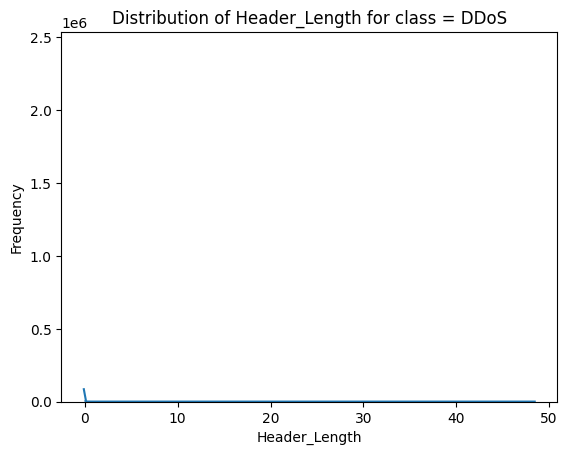

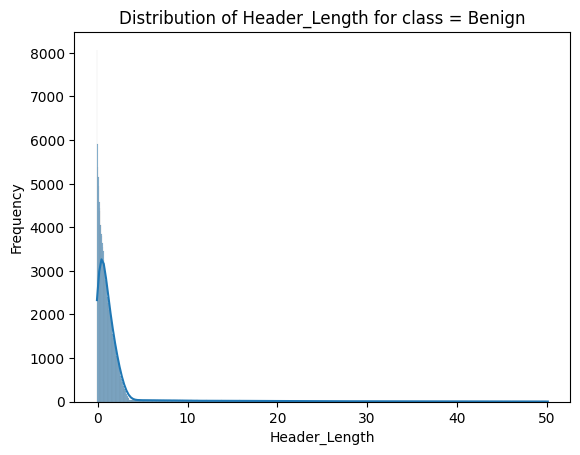

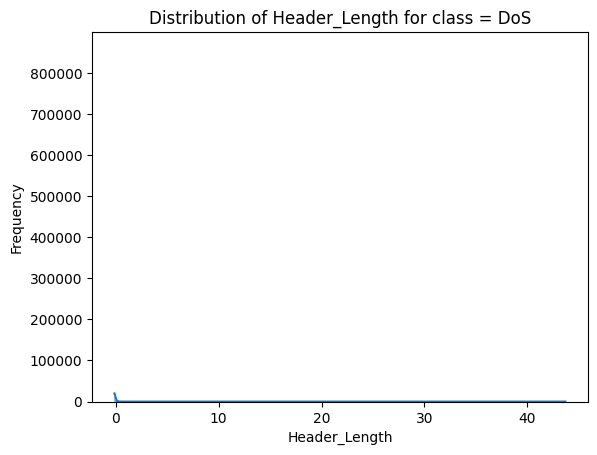

In [12]:
plot_distribution_by_category(df_train, 'class', 'Header_Length')

##### df_val

In [26]:
df_val.describe()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1407186.0,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,...,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06,1.407186e+06
mean,4.529712e-04,2.341064e-03,7.788221e-04,2.001724e-03,2.001724e-03,0.0,1.335087e-03,8.482347e-05,-2.567771e-04,2.188461e-04,...,-1.226642e-03,-1.880989e-03,-1.201147e-03,3.938046e-04,4.256576e-04,-1.135649e-03,-1.889677e-03,-2.030572e-03,1.055229e-03,4.115824e-04
std,1.007257e+00,1.000535e+00,1.002411e+00,1.010757e+00,1.010757e+00,0.0,1.004403e+00,1.000166e+00,9.996710e-01,9.989591e-01,...,9.942200e-01,9.917995e-01,9.947539e-01,9.997599e-01,9.996023e-01,9.943035e-01,9.917707e-01,9.896205e-01,1.001364e+00,9.997247e-01
min,-1.106279e-01,-1.272473e+00,-9.168641e+00,-3.898242e-01,-3.898242e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-2.173308e-01,-1.591168e-01,-2.181501e-01,-6.015280e+00,-1.278166e+01,-4.216992e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,-8.215143e+00
25%,-1.106081e-01,-1.106673e+00,-9.951439e-02,-3.896578e-01,-3.896578e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-2.158119e-01,-1.591168e-01,-2.120718e-01,-1.873871e-04,1.475784e-03,-4.175237e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
50%,-1.100794e-01,-3.250487e-01,-9.951439e-02,-3.860351e-01,-3.860351e-01,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-1.163911e-01,-1.591168e-01,-1.168454e-01,1.030730e-03,1.475784e-03,-1.316856e-01,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
75%,-1.077910e-02,1.411895e+00,-9.951439e-02,9.724571e-02,9.724571e-02,0.0,-1.495520e-01,-4.623321e-01,-2.821236e-01,-2.283066e-01,...,-6.592131e-02,-1.591168e-01,-6.619298e-02,1.062718e-03,1.475784e-03,4.595098e-03,-1.589757e-01,-1.205885e-01,-3.862669e-01,1.415594e-03
max,5.008891e+01,1.411895e+00,2.696616e+01,5.240841e+01,5.240841e+01,0.0,2.900805e+01,2.521477e+00,8.327025e+00,1.017790e+01,...,1.835556e+01,1.991632e+01,1.842192e+01,6.022784e+00,8.272915e+00,1.551010e+01,1.994005e+01,2.743582e+01,4.070029e+00,6.025722e+00


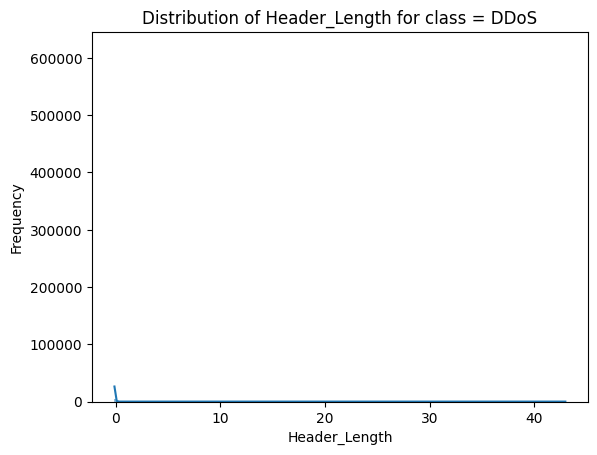

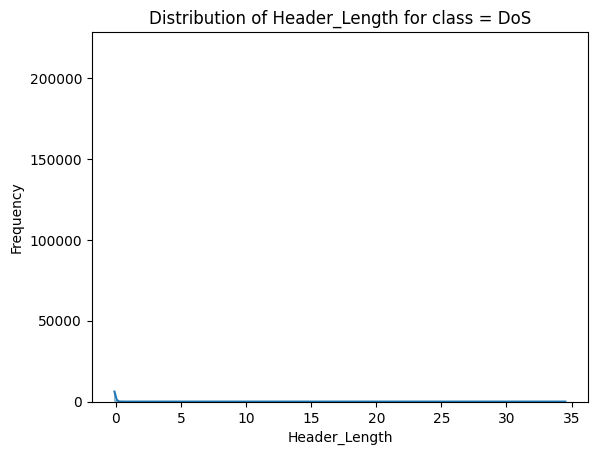

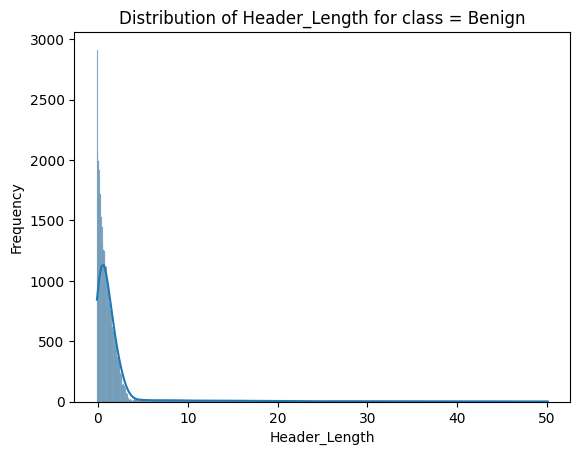

In [20]:
plot_distribution_by_category(df_val, 'class', 'Header_Length')


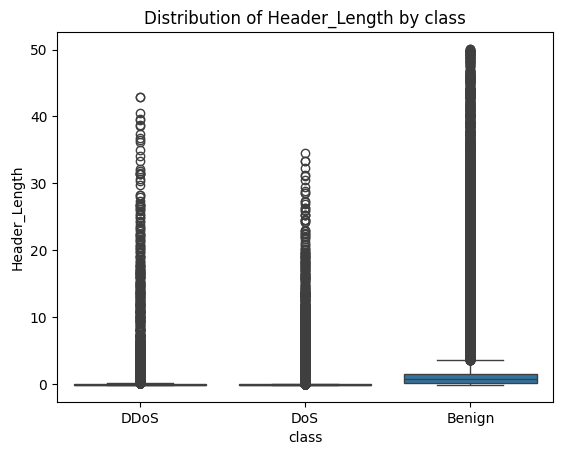

In [94]:
plot_distribution_by_category_box(df_val, 'class', 'Header_Length')

##### data balancing  

In [ ]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek()
# train_smt, train_label_smt = smt.fit_resample(train, train_label)
val_smt, val_label_smt = smt.fit_resample(val, val_label)


In [ ]:
df_val_label_smt = pd.DataFrame(val_label_smt, columns=[oneHot.categories_[0]])
df_val_smt = pd.DataFrame(val_smt, columns=[oneHot.categories_[0]])

<built-in method upper of str object at 0x76df3f8fcc20> columns count : 
Benign    996204
DDoS      989086
DoS       989085
dtype: int64


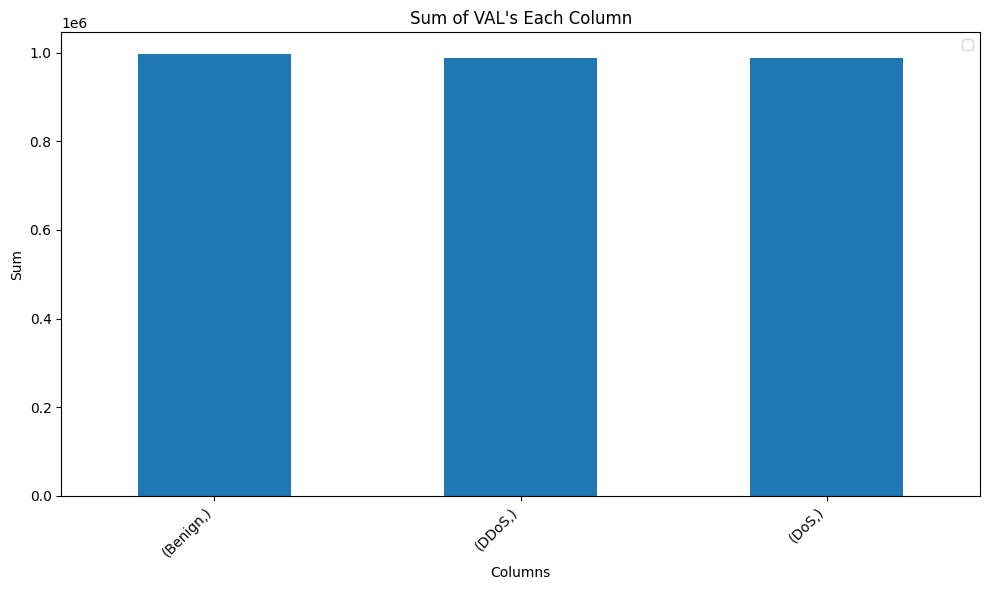

In [30]:

plot_column_sums(df_val_label_smt, "val")

In [ ]:
plot_distribution_by_category_box(df_val_smt, 'class', 'Header_Length')

In [31]:
df_val_label_smt.to_csv('./df_val_label_smt.csv')

##### simple upsampling

In [5]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
# train_smt, train_label_smt = smt.fit_resample(train, train_label)
train_ros, train_label_ros = ros.fit_resample(train, train_label)

In [18]:
df_train_label_ros = pd.DataFrame(train_label_ros, columns=[oneHot.categories_[0]])
train_label_ros_re = oneHot.inverse_transform(train_label_ros)
df_train_ros = pd.DataFrame(train_ros, columns=colnames)
df_train_ros["class"] = train_label_ros_re[:,0]
df_train_ros.head()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,class
0,-0.110354,-0.325049,-0.099514,-0.389796,-0.389796,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001011,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
1,-0.110354,-0.325049,-0.099514,-0.389673,-0.389673,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001010,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
2,-0.110354,-0.325049,-0.099514,-0.386914,-0.386914,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.066193,0.001003,0.001476,0.004595,-0.158976,-0.120588,-0.386267,0.001416,DDoS
3,0.657770,-0.325049,-0.099514,-0.389798,-0.389798,0.0,-0.149552,-0.462332,-0.282124,4.974796,...,0.193904,0.213661,6.022331,6.017068,0.681844,0.193817,-0.112087,4.070029,6.025722,Benign
4,-0.110628,-1.114569,-0.099514,-0.389703,-0.389703,0.0,-0.149552,-0.462332,-0.282124,-0.228307,...,-0.159117,-0.218150,-0.000168,0.001476,-0.421699,-0.158976,-0.120588,-0.386267,0.001416,DoS


<built-in method upper of str object at 0x7b635d5b9130> columns count : 
Benign    3984313
DDoS      3984313
DoS       3984313
dtype: int64


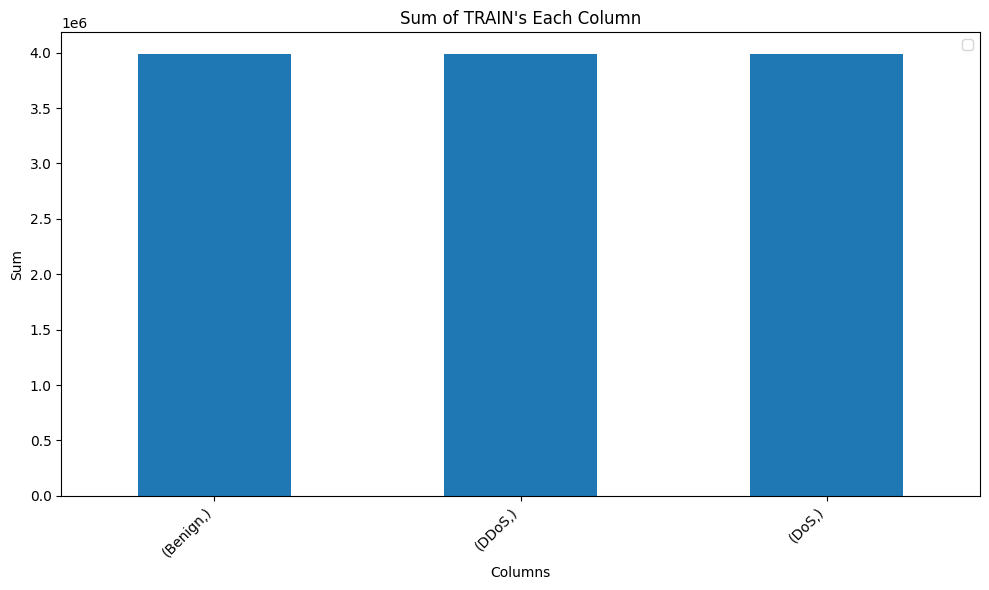

In [12]:
plot_column_sums(df_train_label_ros, "train")

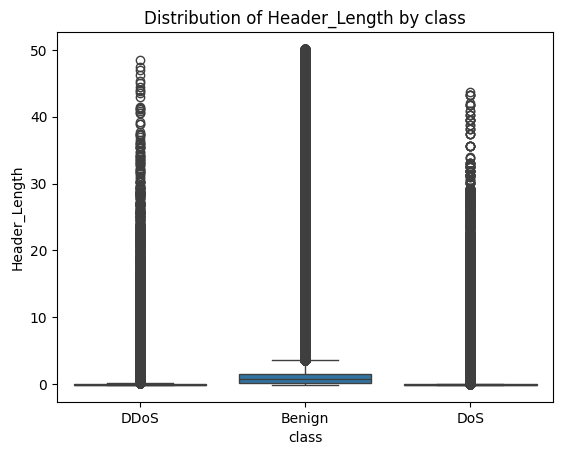

In [19]:
plot_distribution_by_category_box(df_train_ros, 'class', 'Header_Length')

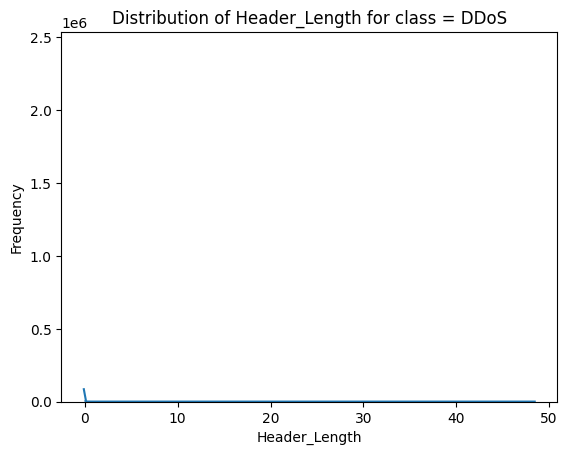

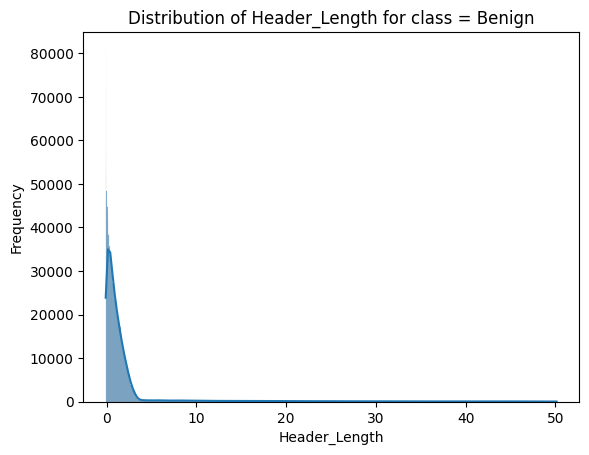

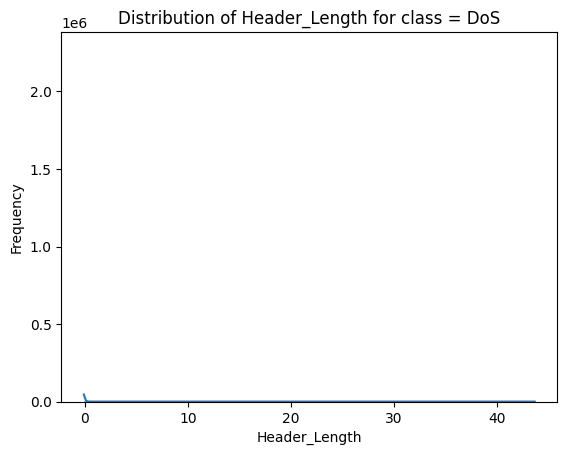

In [20]:
plot_distribution_by_category(df_train_ros, 'class', 'Header_Length')

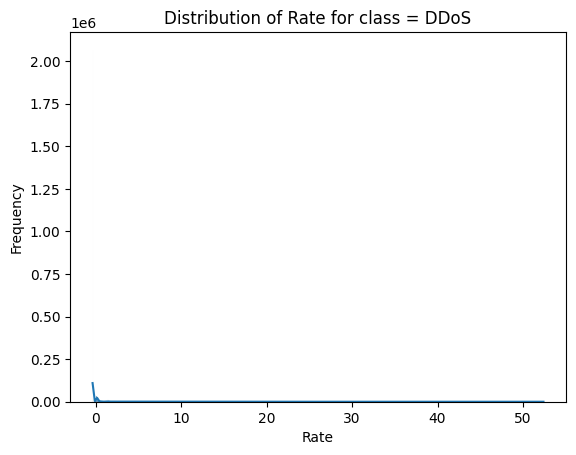

In [ ]:
# memory overflow
# plot_distribution_by_category(df_train_ros, 'class', 'Rate')